In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from  scipy.stats import norm,lognorm
import matplotlib.pyplot as plt

In [4]:
data = yf.download(tickers='AAPL',period='1y')
prices = data['Adj Close'].dropna()
data['Log Returns'] = np.log(data['Adj Close']/data['Adj Close'].shift(1))
log_returns = data['Log Returns'].dropna()


shape,loc,scale = lognorm.fit(prices)
x = np.linspace(min(prices),max(prices),100)
pdf_lognorm = lognorm.pdf(x,shape,loc,scale)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(prices,bins=50,density=True)
plt.plot(x,pdf_lognorm)




mu, sigma = norm.fit(log_returns)
x = np.linspace(min(log_returns),max(log_returns),100)
pdf_norm = norm.pdf(x,mu, sigma)
plt.subplot(1,2,2)
plt.hist(log_returns,bins=50,density=True)
plt.plot(x,pdf_norm)


[*********************100%***********************]  1 of 1 completed


KeyError: 'Adj Close'

In [5]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-05-02,204.458893,206.091775,201.282733,205.195672,101010600
2025-05-05,198.026917,203.214314,197.349875,202.218654,69018500
2025-05-06,197.648544,199.779257,196.165020,197.349858,51216500
2025-05-07,195.398376,198.574536,192.411395,198.305703,68536700
2025-05-08,196.633011,199.181899,193.835192,196.862009,50478900
...,...,...,...,...,...
2026-04-27,267.609985,268.359985,265.070007,266.089996,41466800
2026-04-28,270.709991,273.230011,268.660004,272.339996,40018900


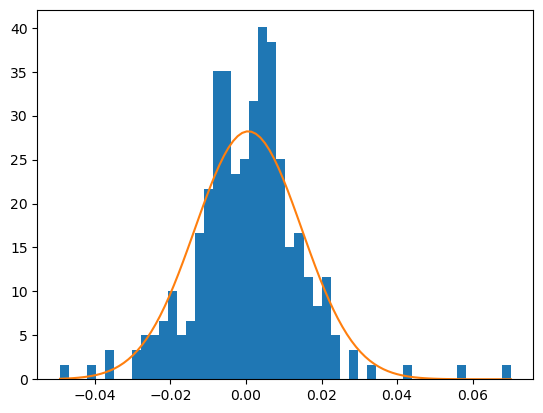